In [62]:
import sys
import json
from pathlib import Path

import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np

from pyproj import CRS

sys.path.append(str(Path.cwd().parent))

In [96]:
# Importa metodos
import src.destinations as destinations
import src.visualization as visualization

In [97]:
import importlib

importlib.reload(destinations)
importlib.reload(visualization)

<module 'src.visualization' from 'c:\\Users\\simon\\Documents\\GitHub\\EtPilot\\src\\visualization.py'>

In [64]:
CURRENT_DIR = Path.cwd()


# Identifica a raiz do projeto
# Retorna um nível para chegar à raiz do repositório
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR


# Constroi o caminho do arquivo de configuração
# sempre a partir da raiz do projeto
CONFIG_FILE = (
    PROJECT_ROOT
    / "config"
    / "config.json"
)


print("Diretório atual:")
print(CURRENT_DIR)

print("\nRaiz do projeto:")
print(PROJECT_ROOT)

print("\nArquivo de configuração:")
print(CONFIG_FILE)

print("\nConfig existe?")
print(CONFIG_FILE.exists())

Diretório atual:
c:\Users\simon\Documents\GitHub\EtPilot\notebooks

Raiz do projeto:
c:\Users\simon\Documents\GitHub\EtPilot

Arquivo de configuração:
c:\Users\simon\Documents\GitHub\EtPilot\config\config.json

Config existe?
True


In [65]:
# Carrega o arquivo de json de configuração

with open(
    CONFIG_FILE,
    "r",
    encoding="utf-8"
) as config_file:

    config = json.load(config_file)

In [66]:
# Pega do arquivo JSON as informações da área de estudo.

PLACE = config["study_area"]["place"]
CRS_PROJETADO = config["study_area"]["crs"]
NETWORK_TYPE = config["study_area"]["network_type"]


# Constroio os caminhos absolutos dos arquivos utilizando
# sempre a raiz do projeto como referência

GRAPH_FILE = (
    PROJECT_ROOT
    / config["paths"]["graph_file"]
)

DESTINATIONS_FILE = (
    PROJECT_ROOT
    / config["paths"]["destinations"]
)


print("Área de estudo:", PLACE)
print("CRS:", CRS_PROJETADO)
print("Tipo de rede:", NETWORK_TYPE)

print("\nGrafo:")
print(GRAPH_FILE)

print("\nDestinos:")
print(DESTINATIONS_FILE)

print("\nGrafo existe?")
print(GRAPH_FILE.exists())

Área de estudo: Porto Alegre, Rio Grande do Sul, Brasil
CRS: EPSG:31982
Tipo de rede: drive

Grafo:
c:\Users\simon\Documents\GitHub\EtPilot\data\graph\rede-poa.graphml

Destinos:
c:\Users\simon\Documents\GitHub\EtPilot\data\o-d\destinos_porto_alegre.gpkg

Grafo existe?
True


In [67]:
# CARREGA REDE
# Interrompe a execução caso o arquivo da rede não seja encontrado.

if not GRAPH_FILE.exists():
    raise FileNotFoundError(
        f"Não encontrei o arquivo da rede em:\n{GRAPH_FILE}"
    )


# Carrega a rede viária construída nas etapas anteriores

G = ox.load_graphml(
    filepath=GRAPH_FILE
)


print("Rede carregada com sucesso.")

print(
    f"Nós: {G.number_of_nodes():,}"
)

print(
    f"Arestas: {G.number_of_edges():,}"
)

print(
    "CRS da rede:",
    G.graph["crs"]
)

Rede carregada com sucesso.
Nós: 21,244
Arestas: 50,351
CRS da rede: EPSG:31982


In [68]:
# CLASSIFICAÇÃO DOS DESTINOS

# Define as categorias de atividades urbanas utilizadas como destinos na pesquisa

destination_tags = {

    "education": {
        "amenity": [
            "school",
            "college",
            "university"
        ]
    },

    "health": {
        "amenity": [
            "hospital",
            "clinic",
            "doctors"
        ]
    },

    "shopping": {
        "shop": True,
        "amenity": [
            "marketplace"
        ]
    },

    "leisure": {
        "leisure": [
            "park",
            "sports_centre",
            "fitness_centre"
        ],
        "amenity": [
            "cinema",
            "theatre"
        ]
    }
}

In [69]:
# CONSULTA DOS DESTINOS NO OPENSTREETMAP

# Cria uma lista para armazenar os resultados obtidos para cada categoria

destinos_lista = []

# Percorre individualmente as categorias funcionais
for categoria, filtros_osm in destination_tags.items():

    print(
        f"Buscando destinos de {categoria}..."
    )

    # consulta os elementos correspondentes à categoria atual na área de estudo
    gdf_categoria = ox.features_from_place(
        PLACE,
        tags=filtros_osm
    )

    # Remove feições sem geometria ou com geometria vazia
    gdf_categoria = gdf_categoria[
        gdf_categoria.geometry.notna()
        &
        ~gdf_categoria.geometry.is_empty
    ].copy()

    # Registra a categoria funcional associada a cada oportunidade
    gdf_categoria["category"] = categoria

    # Armazena o resultado para posterior união
    destinos_lista.append(
        gdf_categoria
    )

    print(
        f"  → {len(gdf_categoria):,} feições."
    )

Buscando destinos de education...
  → 506 feições.
Buscando destinos de health...
  → 182 feições.
Buscando destinos de shopping...
  → 1,934 feições.
Buscando destinos de leisure...
  → 980 feições.


In [70]:
print(Path.cwd())

c:\Users\simon\Documents\GitHub\EtPilot\notebooks


In [71]:
# Reune todas as categorias em um único GeoDataFrame

destinos = pd.concat(
    destinos_lista
)


destinos = gpd.GeoDataFrame(
    destinos,
    geometry="geometry",
    crs=destinos_lista[0].crs
)


print(
    f"\nTotal inicial: {len(destinos):,} registros."
)


Total inicial: 3,602 registros.


In [72]:
destinos["category"].value_counts()

category
shopping     1934
leisure       980
education     506
health        182
Name: count, dtype: int64

In [73]:
destinos[
    [
        "category",
        "name",
        "amenity",
        "shop",
        "leisure"
    ]
].head(30)

category                                           name  \
element id                                                                     
node    853665205   education             Fatepa Faculdade e Cursos Técnicos   
        1118102920  education                        Colégio Marista Ipanema   
        1246428101  education               Universidade São Leopoldo Mandic   
        1286851292  education        Centro de Ensino e Treinamento em Saúde   
        1455553197  education               Faculdade São Francisco de Assis   
        2153926298  education                   SENAC Administração Regional   
        2422063322  education                                           CPOR   
        2429353948  education                       Unificado Pré-vestibular   
        2503991373  education                           Escola Frei Pacífico   
        3260692640  education                             Colégio Tiradentes   
        3282604467  education             Escola Estado do Rio Grande do Sul   
        3295535191  education              Escola Maurício Sirotsky Sobrinho   
        3324209078  education                     Colégio Romano Santa Marta   
        3350596591  education                          Colégio Universitário   
        3386258155  education   Escola Especial Luiz Francisco Lucena Borges   
        3386258156  education                          Escola Eva Carminatti   
        3386258157  education                Escola São Francisco - Santa Fé   
        3386258158  education  Escola de Educação Especial Nazareth Apae Poa   
        3386293411  education                            Escola Alceu Wamosy   
        3386293412  education                    Escola Doutor Miguel Tostes   
        3386293413  education   Escola Especial Educandário São João Batista   
        3386293414  education             Escola Genoveva da Costa Bernardes   
        3387821742  education                             Escola Madre Raffo   
        3590752327  education                         Escola Lauro Rodrigues   
        3590752329  education                        Escola Machado de Assis   
        3590752330  education                           Escola Nações Unidas   
        3590752331  education                          Escola Pepita de Leão   
        3590752332  education                     Escola Visconde de Pelotas   
        3605497470  education                           Escola Victor Issler   
        3684630345  education                 Centro de Tecnologia Acadêmica   

                       amenity shop leisure  
element id                                   
node    853665205      college  NaN     NaN  
        1118102920      school  NaN     NaN  
        1246428101  university  NaN     NaN  
        1286851292      school  NaN     NaN  
        1455553197      school  NaN     NaN  
        2153926298     college  NaN     NaN  
        2422063322      school  NaN     NaN  
        2429353948      school  NaN     NaN  
        2503991373      school  NaN     NaN  
        3260692640      school  NaN     NaN  
        3282604467      school  NaN     NaN  
        3295535191      school  NaN     NaN  
        3324209078      school  NaN     NaN  
        3350596591      school  NaN     NaN  
        3386258155      school  NaN     NaN  
        3386258156      school  NaN     NaN  
        3386258157      school  NaN     NaN  
        3386258158      school  NaN     NaN  
        3386293411      school  NaN     NaN  
        3386293412      school  NaN     NaN  
        3386293413      school  NaN     NaN  
        3386293414      school  NaN     NaN  
        3387821742      school  NaN     NaN  
        3590752327      school  NaN     NaN  
        3590752329      school  NaN     NaN  
        3590752330      school  NaN     NaN  
        3590752331      school  NaN     NaN  
        3590752332      school  NaN     NaN  
        3605497470      school  NaN     NaN  
        3684630345  university  Na

In [78]:
# Remove classificações genéricas ou que indicam ausência/inatividade do estabelecimento comercial

shop_excluir = {
    "yes",
    "no",
    "vacant",
    "construction"
}


mask_shop_invalido = (
    (destinos["category"] == "shopping")
    &
    destinos["shop"].isin(shop_excluir)
)


destinos = destinos[
    ~mask_shop_invalido
].copy()


print(
    f"Total após limpeza: {len(destinos):,}"
)

destinos["category"].value_counts()

Total após limpeza: 0


Series([], Name: count, dtype: int64)

In [80]:
destinos = pd.concat(
    destinos_lista
)

destinos = gpd.GeoDataFrame(
    destinos,
    geometry="geometry",
    crs=destinos_lista[0].crs
)

print(
    f"Total reconstruído: {len(destinos):,}"
)

print(
    destinos["category"].value_counts()
)

Total reconstruído: 3,602
category
shopping     1934
leisure       980
education     506
health        182
Name: count, dtype: int64


In [82]:
# Preserva a classificação mais específica disponível no OpenStreetMap para cada destino.

destinos["subcategory"] = destinos.apply(destinations.obter_subcategoria, axis=1)

In [83]:
destinos.groupby(
    [
        "category",
        "subcategory"
    ]
).size()

category   subcategory
education  college         26
           school         438
           university      42
health     clinic          98
           doctors         32
                         ... 
shopping   video            2
           water            4
           wholesale        2
           wine             4
           yes             54
Length: 140, dtype: int64

In [84]:
# REPROJEÇÃO

# Reprojeta os destinos para o CRS métrico adotado no restante da pesquisa

destinos = destinos.to_crs(
    CRS_PROJETADO
)

In [85]:
destinos.geometry.geom_type.value_counts()

Polygon         2013
Point           1576
MultiPolygon      12
LineString         1
Name: count, dtype: int64

In [86]:
# REPRESENTAÇÃO PONTUAL

# Converte as oportunidades espaciais para pontos, pois posteriormente serao associadas a rede
# Manter os objetos originalmente pontuais e utilizar representative_point() para os demais tipos de geometria

destinos["geometry"] = destinos.geometry.apply(
    lambda geom:
        geom
        if geom.geom_type == "Point"
        else geom.representative_point()
)

In [87]:
destinos.geometry.geom_type.value_counts()

Point    3602
Name: count, dtype: int64

In [ ]:
# ASSOCIAR A REDE
# Garantir que os destinos estejam representados no mesmo CRS utilizado pelo grafo

destinos = destinos.to_crs(
    G.graph["crs"]
)


# Encntrar o nó viário mais próximo de cada destino

destinos["node"] = ox.distance.nearest_nodes(
    G,
    X=destinos.geometry.x.to_numpy(),
    Y=destinos.geometry.y.to_numpy()
)

In [89]:
destinos[
    [
        "category",
        "subcategory",
        "name",
        "node"
    ]
].head(30)

category subcategory  \
element id                                  
node    853665205   education     college   
        1118102920  education      school   
        1246428101  education  university   
        1286851292  education      school   
        1455553197  education      school   
        2153926298  education     college   
        2422063322  education      school   
        2429353948  education      school   
        2503991373  education      school   
        3260692640  education      school   
        3282604467  education      school   
        3295535191  education      school   
        3324209078  education      school   
        3350596591  education      school   
        3386258155  education      school   
        3386258156  education      school   
        3386258157  education      school   
        3386258158  education      school   
        3386293411  education      school   
        3386293412  education      school   
        3386293413  education      school   
        3386293414  education      school   
        3387821742  education      school   
        3590752327  education      school   
        3590752329  education      school   
        3590752330  education      school   
        3590752331  education      school   
        3590752332  education      school   
        3605497470  education      school   
        3684630345  education  university   

                                                             name        node  
element id                                                                     
node    853665205              Fatepa Faculdade e Cursos Técnicos  3244520885  
        1118102920                        Colégio Marista Ipanema  3338368764  
        1246428101               Universidade São Leopoldo Mandic   297360393  
        1286851292        Centro de Ensino e Treinamento em Saúde   489910196  
        1455553197               Faculdade São Francisco de Assis   613086833  
        2153926298                   SENAC Administração Regional   830128126  
        2422063322                                           CPOR  8484958926  
        2429353948                       Unificado Pré-vestibular  1456161584  
        2503991373                           Escola Frei Pacífico   473697529  
        3260692640                             Colégio Tiradentes  8717913997  
        3282604467             Escola Estado do Rio Grande do Sul   296254343  
        3295535191              Escola Maurício Sirotsky Sobrinho   313255420  
        3324209078                     Colégio Romano Santa Marta   317715767  
        3350596591                          Colégio Universitário   448034982  
        3386258155   Escola Especial Luiz Francisco Lucena Borges  6129824255  
        3386258156                          Escola Eva Carminatti  3386266007  
        3386258157                Escola São Francisco - Santa Fé  2326337039  
        3386258158  Escola de Educação Especial Nazareth Apae Poa   617904625  
        3386293411                            Escola Alceu Wamosy   571497636  
        3386293412                    Escola Doutor Miguel Tostes   852134829  
        3386293413   Escola Especial Educandário São João Batista  8709116042  
        3386293414             Escola Genoveva da Costa Bernardes  2915323282  
        3387821742                             Escola Madre Raffo  1027627669  
        3590752327                         Escola Lauro Rodrigues  8424170077  
        3590752329                        Escola Machado de Assis   832662695  
        3590752330                           Escola Nações Unidas   477246622  
        3590752331                          Escola Pepita de Leão   877793696  
        3590752332                     Escola Visconde de Pelotas   479081849  
        3605497470                           Escola Victor Issler   321395405  
        3684630345                 Centro de Tecnologia Acadêmica   345846981

In [90]:
destinos.groupby(
    [
        "category",
        "node"
    ]
).size().sort_values(
    ascending=False
).head(30)

category  node      
shopping  479071726     29
          660496075     26
          477240716     19
          2911552924    15
          477240667     14
          443403694     13
          508060255     13
          4484793175    11
          477240753     11
          295523686     11
          477240656     11
          611963070     10
          477240639     10
          321231531      9
          297620730      9
          477240504      9
          836544978      9
          660496127      9
          477240503      9
          834378698      8
          8427764778     8
          2186514447     8
          634173877      8
          443403724      8
          1906959907     8
          319531583      8
          295523692      8
          298009941      7
          319119091      7
          330048365      7
dtype: int64

In [91]:
# NÓS COM MAIOR CONCENTRAÇÃO DE DESTINOS

# Conta quantos estabelecimentos de cada categoria foram associados a cada nó da rede.

destinos_por_no = (
    destinos
    .groupby(
        [
            "category",
            "node"
        ]
    )
    .size()
    .reset_index(
        name="destination_weight"
    )
)


# Seleciona os 30 nós com maior concentração de destinos.

top_destinos = (
    destinos_por_no
    .sort_values(
        "destination_weight",
        ascending=False
    )
    .head(30)
    .copy()
)


top_destinos

,category,node,destination_weight
2039,shopping,479071726,29
2133,shopping,660496075,26
2010,shopping,477240716,19
2442,shopping,2911552924,15
2007,shopping,477240667,14
1924,shopping,443403694,13
2065,shopping,508060255,13
2511,shopping,4484793175,11
2011,shopping,477240753,11
1582,shopping,295523686,11


In [ ]:
# GEOMETRIA DOS NÓS DE DESTINO

# Extrai os nós e as arestas da rede como GeoDataFrames

gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)


# Prepara uma tabela contendo o identificador e a geometria de cada nó da rede.

nodes_geometry = (
    gdf_nodes[
        ["geometry"]
    ]
    .reset_index()
)


# Padroniza o nome da coluna que contém o identificador do nó

nodes_geometry = nodes_geometry.rename(
    columns={
        nodes_geometry.columns[0]: "node"
    }
)


nodes_geometry.head()

,node,geometry
0,144956850,POINT (480634.385 6683510.478)
1,4449912655,POINT (480549.433 6683204.088)
2,144956861,POINT (482695.945 6684545.542)
3,321304272,POINT (482458.292 6684521.256)
4,144956862,POINT (483429.784 6684620.076)


In [94]:
# Associa a geometria da rede aos nós selecionados como principais destinos.

top_destinos = (
    top_destinos
    .merge(
        nodes_geometry,
        on="node",
        how="left"
    )
)


# Transforma o resultado em GeoDataFrame

top_destinos = gpd.GeoDataFrame(
    top_destinos,
    geometry="geometry",
    crs=gdf_nodes.crs)

top_destinos.head()

,category,node,destination_weight,geometry
0,shopping,479071726,29,POINT (480547.614 6678572.12)
1,shopping,660496075,26,POINT (478555.825 6678078.466)
2,shopping,477240716,19,POINT (478229.251 6677831.874)
3,shopping,2911552924,15,POINT (478243.597 6678018.095)
4,shopping,477240667,14,POINT (478329.243 6677823.793)


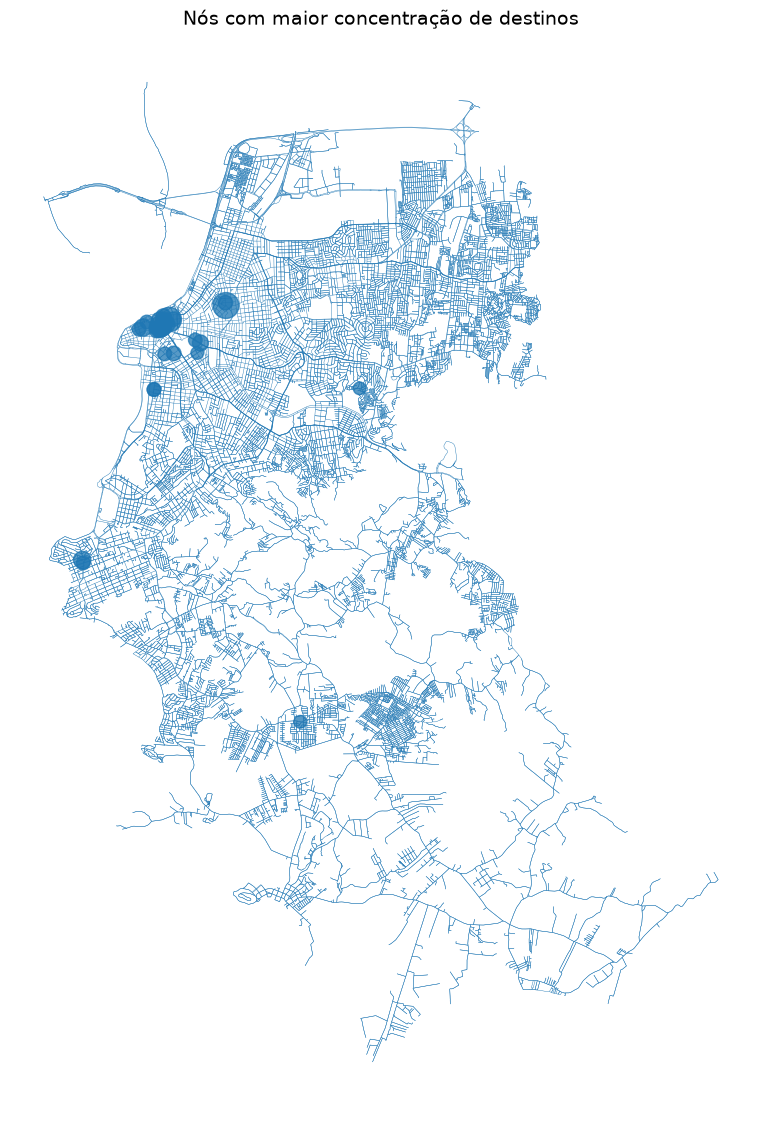

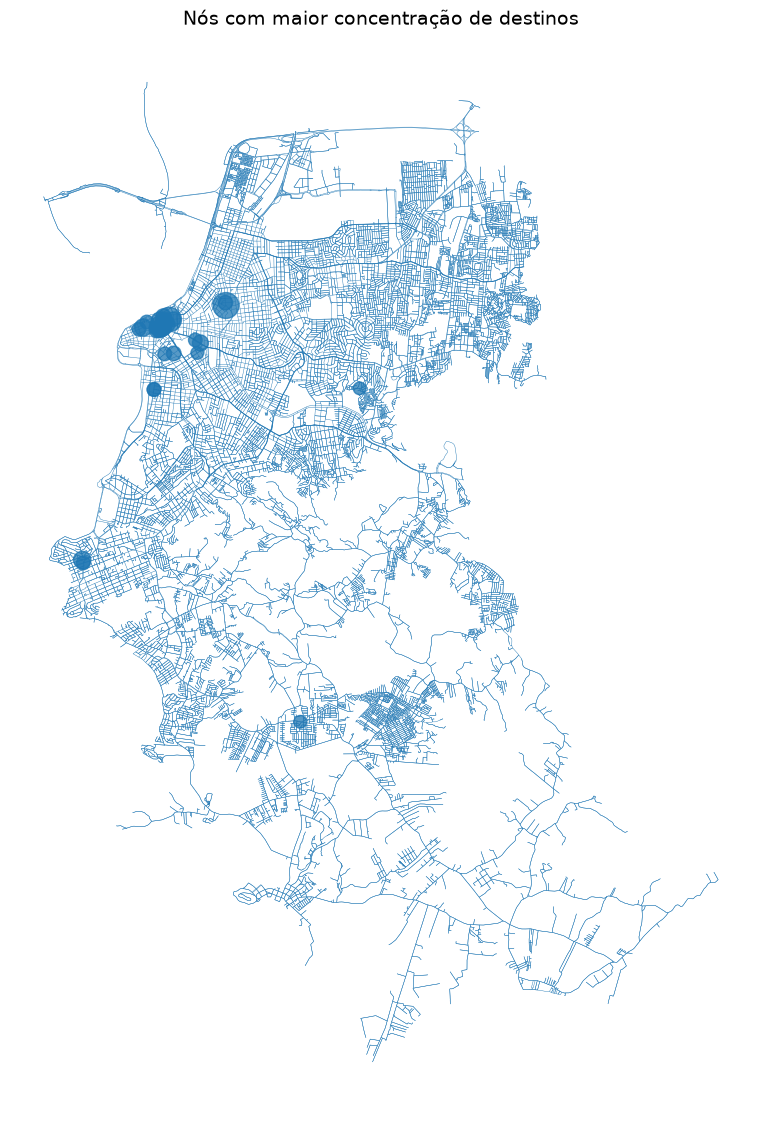

In [ ]:
# ============================================================
# VISUALIZAÇÃO DOS PRINCIPAIS DESTINOS
# ============================================================

# Plota a rede viária de Porto Alegre

fig, ax = visualization.plot_network(
    gdf_edges,
    figsize=(14, 14),
    legend=False,
    linewidth=0.3
)


# Sobrepoe os nós que concentram o maior número de destinos.
# O tamanho dos pontos varia conforme a quantidade de estabelecimentos associados ao nó.

top_destinos.plot(
    ax=ax,
    markersize=(
        top_destinos["destination_weight"]
        * 12
    ),
    alpha=0.75
)


ax.set_title(
    "Nós com maior concentração de destinos",
    fontsize=14
)

fig

In [99]:
# AGREGAÇÃO DOS DESTINOS

# RegistrA a quantidade de oportunidades existentes antes da agregação para verificar posteriormente se nenhuma informação foi perdida.

n_destinos_originais = len(destinos)

print(
    f"Destinos antes da agregação: "
    f"{n_destinos_originais:,}"
)

Destinos antes da agregação: 3,602


In [101]:
# Agrega os estabelecimentos que pertencem à mesma
# categoria funcional e foram associados ao mesmo nó

# A quantidade de estabelecimentos agregados passa a ser o peso daquele destino na rede.

destinos_agregados = (
    destinos
    .groupby(
        [
            "category",
            "node"
        ],
        as_index=False
    )
    .agg(

        destination_weight=(
            "node",
            "size"
        ),

        n_subcategories=(
            "subcategory",
            "nunique"
        )
    )
)

In [102]:
destinos_agregados.sort_values(
    "destination_weight",
    ascending=False
).head(30)

,category,node,destination_weight,n_subcategories
2039,shopping,479071726,29,12
2133,shopping,660496075,26,18
2010,shopping,477240716,19,11
2442,shopping,2911552924,15,10
2007,shopping,477240667,14,11
1924,shopping,443403694,13,11
2065,shopping,508060255,13,7
2511,shopping,4484793175,11,9
2011,shopping,477240753,11,5
1582,shopping,295523686,11,7


In [103]:
# Reune as diferentes subcategorias existentes em cada combinação de categoria e nó

subcategorias_por_no = (
    destinos
    .groupby(
        [
            "category",
            "node"
        ]
    )["subcategory"]
    .apply(
        lambda valores: ";".join(
            sorted(
                {
                    str(valor)
                    for valor in valores.dropna()
                }
            )
        )
    )
    .reset_index(
        name="subcategories"
    )
)

In [104]:
# Incorporo a informação das subcategorias ao conjunto agregado de destinos

destinos_agregados = (
    destinos_agregados
    .merge(
        subcategorias_por_no,
        on=[
            "category",
            "node"
        ],
        how="left"
    )
)

In [105]:
# Extrai os nós da rede em formato GeoDataFrame

gdf_nodes = ox.graph_to_gdfs(
    G,
    edges=False
)

In [107]:
# Prepara a geometria dos nós para associá-la aos destinos agregados.

nodes_geometry = (
    gdf_nodes[
        ["geometry"]
    ]
    .copy()
)


# Padronizoa nome do índice para node.
nodes_geometry.index.name = "node"

# Transfere a geometria exata de cada nó da rede para o respectivo destino agregado

destinos_agregados = (
    destinos_agregados
    .merge(
        nodes_geometry,
        left_on="node",
        right_index=True,
        how="left"
    )
)

In [108]:
destinos_agregados = gpd.GeoDataFrame(
    destinos_agregados,
    geometry="geometry",
    crs=gdf_nodes.crs
)

In [109]:
# Verifica se todos os destinos agregados conseguiram encontrar seu respectivo nó na rede.

n_sem_geometria = (
    destinos_agregados["geometry"]
    .isna()
    .sum()
)


print(
    f"Destinos sem geometria: "
    f"{n_sem_geometria}"
)

Destinos sem geometria: 0


In [110]:
# Define prefixo para cada categoria

prefixos = {
    "education": "EDU",
    "health": "HEA",
    "shopping": "SHO",
    "leisure": "LEI"
}

In [ ]:
# Cria uma sequência independente dentro de cada categoria funcional

destinos_agregados = (
    destinos_agregados
    .sort_values(
        [
            "category",
            "node"
        ]
    )
    .reset_index(
        drop=True
    )
)


destinos_agregados["numero_categoria"] = (
    destinos_agregados
    .groupby("category")
    .cumcount()
    + 1
)

In [113]:
# Constroi um identificador único e estável para cada destino agregado.

destinos_agregados["destination_id"] = (
    destinos_agregados.apply(
        lambda row:
            f"{prefixos[row['category']]}_"
            f"{row['numero_categoria']:05d}",
        axis=1
    )
)


In [115]:
# ESTRUTURA FINAL

# Mantem somente as informações necessárias para as próximas etapas

destinos_final = destinos_agregados[
    [
        "destination_id",
        "category",
        "node",
        "destination_weight",
        "n_subcategories",
        "subcategories",
        "geometry"
    ]
].copy()

destinos_final.head(20)

,destination_id,category,node,destination_weight,n_subcategories,subcategories,geometry
0,EDU_00001,education,293823357,1,1,college,POINT (483683.336 6674919.973)
1,EDU_00002,education,293823550,1,1,school,POINT (488104.226 6672684.24)
2,EDU_00003,education,294899675,1,1,school,POINT (480994.03 6674919.333)
3,EDU_00004,education,295145441,1,1,school,POINT (479298.383 6675935.874)
4,EDU_00005,education,295165445,1,1,school,POINT (479146.535 6676642.21)
5,EDU_00006,education,295513151,1,1,school,POINT (483686.241 6675203.794)
6,EDU_00007,education,295520433,1,1,school,POINT (480835.712 6676795.675)
7,EDU_00008,education,295523072,1,1,university,POINT (478866.909 6677569.763)
8,EDU_00009,education,295523700,1,1,school,POINT (479235.32 6677501.716)
9,EDU_00010,education,296254332,1,1,school,POINT (476922.788 6677169.083)


In [116]:
destinos_final.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2617 entries, 0 to 2616
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   destination_id      2617 non-null   str     
 1   category            2617 non-null   str     
 2   node                2617 non-null   int64   
 3   destination_weight  2617 non-null   int64   
 4   n_subcategories     2617 non-null   int64   
 5   subcategories       2617 non-null   str     
 6   geometry            2617 non-null   geometry
dtypes: geometry(1), int64(3), str(3)
memory usage: 209.8 KB


### Validações

In [117]:
# VALIDAÇÃO DA AGREGAÇÃO

# Soma os pesos dos destinos agregados
# Esse resultado precisa ser exatamente igual à quantidade de oportunidades existentes antes da agregação.

peso_total_agregado = (
    destinos_final[
        "destination_weight"
    ]
    .sum()
)


print(
    f"Destinos antes da agregação: "
    f"{n_destinos_originais:,}"
)

print(
    f"Soma dos pesos após agregação: "
    f"{peso_total_agregado:,}"
)

print(
    "Validação:",
    n_destinos_originais
    == peso_total_agregado
)

Destinos antes da agregação: 3,602
Soma dos pesos após agregação: 3,602
Validação: True


In [118]:
# Compara a quantidade original de oportunidades com a soma dos pesos após a agregação para cada categoria.

validacao_original = (
    destinos
    .groupby("category")
    .size()
    .rename("n_original")
)


validacao_agregada = (
    destinos_final
    .groupby("category")[
        "destination_weight"
    ]
    .sum()
    .rename("peso_agregado")
)


validacao_categoria = pd.concat(
    [
        validacao_original,
        validacao_agregada
    ],
    axis=1
)


validacao_categoria[
    "valido"
] = (
    validacao_categoria["n_original"]
    ==
    validacao_categoria["peso_agregado"]
)


validacao_categoria

,n_original,peso_agregado,valido
category,,,
education,506,506,True
health,182,182,True
leisure,980,980,True
shopping,1934,1934,True


In [119]:
# Calcula quantos destinos efetivamente precisarão ser utilizados no roteamento

n_destinos_agregados = len(
    destinos_final
)


reducao_pct = (
    1
    -
    n_destinos_agregados
    / n_destinos_originais
) * 100


print(
    f"Oportunidades individuais: "
    f"{n_destinos_originais:,}"
)

print(
    f"Nós de destino: "
    f"{n_destinos_agregados:,}"
)

print(
    f"Redução: "
    f"{reducao_pct:.2f}%"
)

Oportunidades individuais: 3,602
Nós de destino: 2,617
Redução: 27.35%


In [120]:
resumo_final = (
    destinos_final
    .groupby("category")
    .agg(

        destination_nodes=(
            "destination_id",
            "size"
        ),

        opportunities=(
            "destination_weight",
            "sum"
        ),

        mean_weight=(
            "destination_weight",
            "mean"
        ),

        max_weight=(
            "destination_weight",
            "max"
        )
    )
)


resumo_final

,destination_nodes,opportunities,mean_weight,max_weight
category,,,,
education,480,506,1.054167,4
health,158,182,1.151899,4
leisure,919,980,1.066376,6
shopping,1060,1934,1.824528,29


### Salvar

In [121]:
# ALVAMENTO

# Garante que a pasta de destino exista.

DESTINATIONS_FILE.parent.mkdir(
    parents=True,
    exist_ok=True
)

In [122]:
# Salvo os destinos agregados em um único GeoPackage

# O layer "destinations" será utilizado pelo próximo notebook para gerar os pares origem-destino.

destinos_final.to_file(
    DESTINATIONS_FILE,
    layer="destinations",
    driver="GPKG"
)

In [124]:
print("Arquivo salvo em:")

print(DESTINATIONS_FILE)

Arquivo salvo em:
c:\Users\simon\Documents\GitHub\EtPilot\data\o-d\destinos_porto_alegre.gpkg
